In [1]:
# ==============================================================================
# CELL 1 : LOADING THE BALANCED DATA
# ==============================================================================
"""
### What is this code about?
* This code imports the pandas library and loads the four CSV files we generated 
  at the end of Week 2 (`X_train_balanced`, `y_train_balanced`, `X_test_final`, `y_test_final`).

### Why are we doing this?
* To train a machine learning model, we must bring our cleaned, SMOTE-balanced 
  features and target variables back into the computer's memory.

### What is the main reason behind it (intent)?
* Loading saved CSVs prevents us from having to rerun the entire Week 1 and Week 2 
  data cleaning and SMOTE processing pipelines. It creates a clean, isolated starting 
  point for the modeling phase, ensuring we don't accidentally leak test data into our training set.

### What will be the result?
* Four pandas DataFrames will be created in memory. 
* We print the shape (number of rows and columns) of the training data to prove 
  to the team that the classes are perfectly balanced before training begins.
"""

import pandas as pd

# 1. Load the balanced training data (used for TEACHING the model)
X_train = pd.read_csv('X_train_balanced.csv')
y_train = pd.read_csv('y_train_balanced.csv')

# 2. Load the untouched testing data (used for TESTING the model)
X_test = pd.read_csv('X_test_final.csv')
y_test = pd.read_csv('y_test_final.csv')

# Ensure y_train and y_test are 1D arrays (Series) rather than 2D DataFrames for the model
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

print("Data successfully loaded!")
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")

Data successfully loaded!
Training Features Shape: (158236, 29)
Testing Features Shape: (20000, 29)


In [2]:
# ==============================================================================
# CELL 2 : TRAINING THE MACHINE LEARNING MODEL
# ==============================================================================
"""
### What is this code about?
* We import the `RandomForestClassifier` from scikit-learn, initialize it, 
  and fit (train) it using our balanced `X_train` and `y_train` datasets.

### Why are we doing this?
* The model needs to learn the underlying patterns that differentiate a normal 
  transaction from a fraudulent one based on the numerical features we provided.

### What is the main reason behind it (intent)?
* We chose Random Forest because it builds multiple "decision trees" and averages 
  their results. This makes it highly accurate and easy to explain to stakeholders. 
* By feeding it the SMOTE-balanced data, we ensure the model pays equal attention 
  to the rare fraud cases instead of just defaulting to "Not Fraud."

### What will be the result?
* The `.fit()` function will execute, completing the training process. 
* The `model` variable will transform from an empty algorithm into a fully trained 
  fraud-detection system, ready to make predictions.
"""

from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the model 
# (random_state ensures the team gets the exact same results every time they run it)
model = RandomForestClassifier(random_state=42)

print("Training the Random Forest model... (This may take a minute depending on data size)")

# 2. Train the model on the balanced data
model.fit(X_train, y_train)

print("Success! The model has been trained.")

Training the Random Forest model... (This may take a minute depending on data size)
Success! The model has been trained.


In [3]:
# ==============================================================================
# CELL 3 : PREDICTIONS AND EVALUATION
# ==============================================================================
"""
### What is this code about?
* The model is used to predict fraud on the `X_test` data (data it has never seen).
* We then generate a Confusion Matrix and a Classification Report to compare the 
  model's predictions (`y_pred`) against the actual real answers (`y_test`).

### Why are we doing this?
* In fraud detection, standard "accuracy" is useless (a model can guess 99% accuracy 
  just by saying no fraud ever happens). We must look at "Recall" (how much of the 
  actual fraud did we catch?) and "Precision" (when we flagged fraud, were we right?).

### What is the main reason behind it (intent)?
* To transparently prove the business value of the model. The confusion matrix shows 
  exactly how many false positives (annoying a real customer) and false negatives 
  (letting a fraudster escape) the model produced.

### What will be the result?
* A detailed statistical report will be printed to the screen.
* It will show the F1-score, Precision, and Recall for both normal (0) and 
  fraudulent (1) transactions, giving the team a clear picture of performance.
"""

from sklearn.metrics import classification_report, confusion_matrix

# 1. Ask the trained model to predict outcomes for the test set
y_pred = model.predict(X_test)

# 2. Print the evaluation metrics
print("=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred))
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

=== CONFUSION MATRIX ===
[[19556   223]
 [  125    96]]

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     19779
           1       0.30      0.43      0.36       221

    accuracy                           0.98     20000
   macro avg       0.65      0.71      0.67     20000
weighted avg       0.99      0.98      0.98     20000



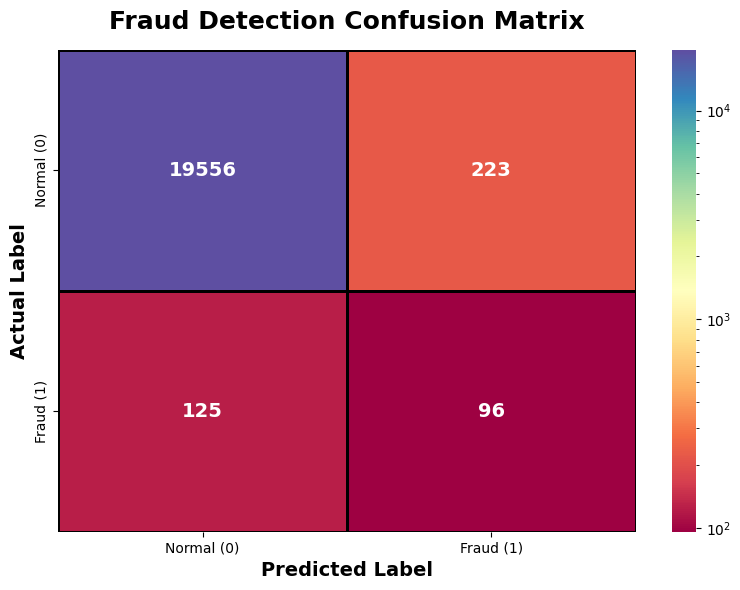

In [4]:
# ==============================================================================
# CELL 4 : VISUALIZING THE CONFUSION MATRIX (LOGARITHMIC SCALE)
# ==============================================================================
"""
### What is this code about?
* We use the `seaborn` and `matplotlib` libraries to create a visual heatmap of 
  the confusion matrix we generated in the previous cell. We also apply a LogNorm 
  scale to ensure all boxes get distinct colors despite large numerical differences.

### Why are we doing this?
* Because the number of True Negatives (normal transactions) is massively larger 
  than the fraud cases, a standard heatmap makes all the fraud boxes look identical. 
  A logarithmic scale fixes this so we can visually distinguish between the smaller error rates.

### What is the main reason behind it (intent)?
* This is purely for stakeholder communication. A clear, distinct visual makes it 
  much easier to explain False Positives (legitimate transactions flagged as fraud) 
  and False Negatives (missed fraud) during a presentation.

### What will be the result?
* A beautifully formatted, multi-colored grid where every single box has a distinct 
  color based on its value, making the model's performance immediately obvious.
"""

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from matplotlib.colors import LogNorm  # <--- NEW IMPORT for Logarithmic Scaling

# 1. Generate the raw confusion matrix again
cm = confusion_matrix(y_test, y_pred)

# 2. Set up the plotting area
plt.figure(figsize=(8, 6))

# 3. Create the heatmap using seaborn with LogNorm
# - norm=LogNorm(): Scales colors logarithmically so small numbers don't share the same color.
sns.heatmap(cm, annot=True, fmt='d', cmap='Spectral', 
            linewidths=1, linecolor='black',
            annot_kws={"size": 14, "weight": "bold"},
            xticklabels=['Normal (0)', 'Fraud (1)'], 
            yticklabels=['Normal (0)', 'Fraud (1)'],
            norm=LogNorm())  # <--- NEW ADDITION

# 4. Add clear labels and title for the presentation
plt.title('Fraud Detection Confusion Matrix', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=14, fontweight='bold')

# 5. Display the plot
plt.tight_layout()
plt.show()

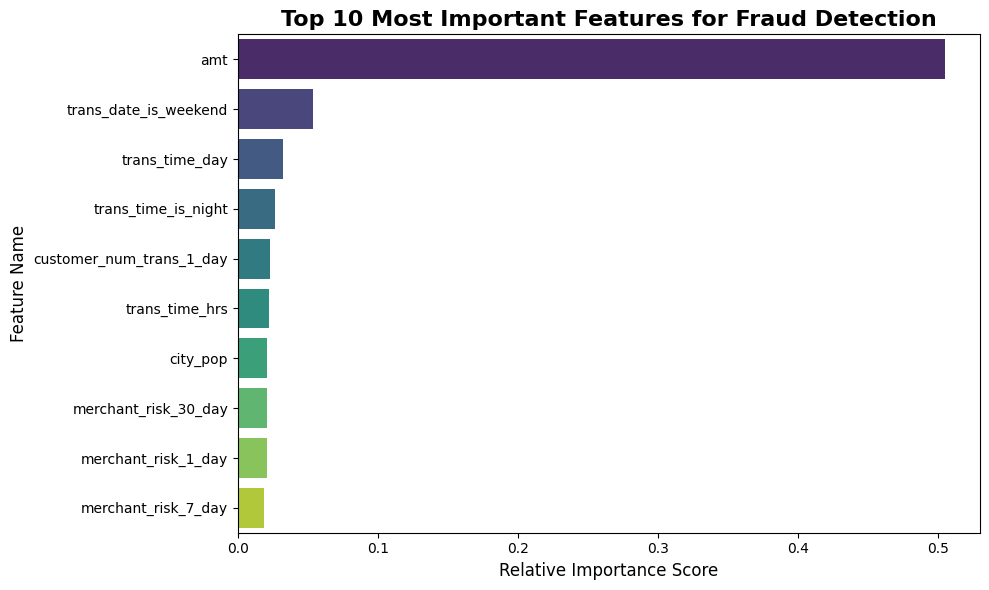

In [5]:
# ==============================================================================
# CELL 5 : ANALYZING FEATURE IMPORTANCE
# ==============================================================================
"""
### What is this code about?
* We extract the 'feature_importances_' attribute from our trained Random Forest model.
* We create a pandas DataFrame to map these importance scores to the original feature names.
* Finally, we visualize the top 10 most influential features using a seaborn bar plot.

### Why are we doing this?
* Machine learning shouldn't be a "black box." We need to understand *why* the model makes its decisions.
* This tells us which variables (e.g., transaction amount, time, specific anonymized features) are the strongest indicators of fraud.

### What is the main reason behind it (intent)?
* To build trust with stakeholders by explaining the model's logic. If the model relies on logical features, the business is more likely to adopt it.
* It also helps us identify if there's any data leakage (a feature that is suspiciously too predictive).

### What will be the result?
* A sorted bar chart displaying the top 10 features that contributed most to identifying fraud.
"""
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get feature importances from the trained model
importances = model.feature_importances_

# 2. Create a DataFrame for easy sorting and plotting
# Using X_train.columns to map the scores to the actual feature names
feature_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# 3. Sort by importance in descending order and select the top 10
top_10_features = feature_df.sort_values(by='Importance', ascending=False).head(10)

# 4. Plot the results
plt.figure(figsize=(10, 6))
# Assigning 'Feature' to 'hue' and setting legend=False to fix the previous seaborn warning
sns.barplot(x='Importance', y='Feature', data=top_10_features, hue='Feature', palette='viridis', legend=False)

plt.title('Top 10 Most Important Features for Fraud Detection', fontsize=16, fontweight='bold')
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()

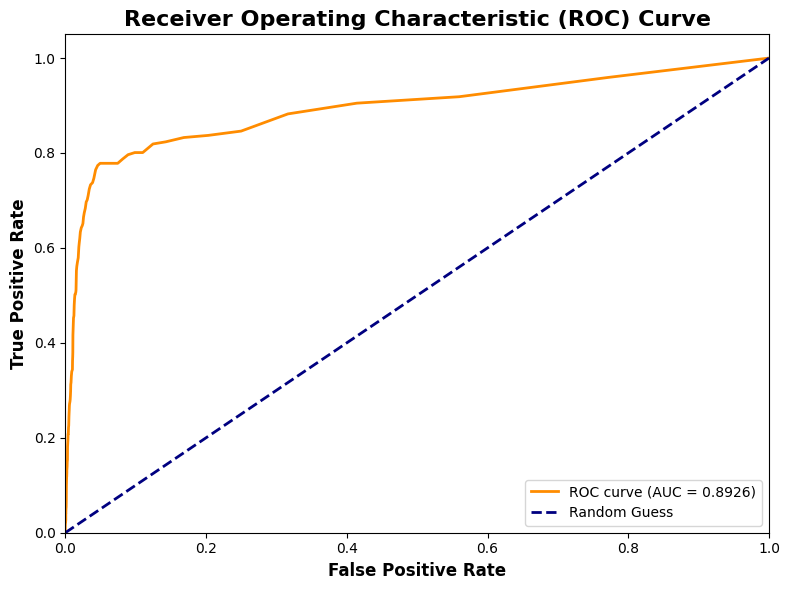

In [6]:
# ==============================================================================
# CELL 6 : ROC CURVE AND AUC SCORE
# ==============================================================================
"""
### What is this code about?
* We calculate the Receiver Operating Characteristic (ROC) curve and the Area Under the Curve (AUC).
* We plot the curve using matplotlib.

### Why are we doing this?
* The ROC curve shows the trade-off between the True Positive Rate (Recall) and the False Positive Rate across different probability thresholds.
* AUC gives us a single metric (from 0 to 1) representing the model's ability to distinguish between normal and fraudulent transactions.

### What is the main reason behind it (intent)?
* Standard classification metrics like 'accuracy' are misleading for imbalanced data. ROC-AUC is an industry-standard way to evaluate and compare classification models mathematically.

### What will be the result?
* A graph showing the ROC curve. A line hugging the top-left corner (AUC close to 1.0) means we have an excellent model.
"""
from sklearn.metrics import roc_curve, auc

# 1. Get the probability scores for the positive class (Fraud = 1)
y_pred_prob = model.predict_proba(X_test)[:, 1]

# 2. Calculate False Positive Rate (fpr), True Positive Rate (tpr), and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# 3. Calculate Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# 4. Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

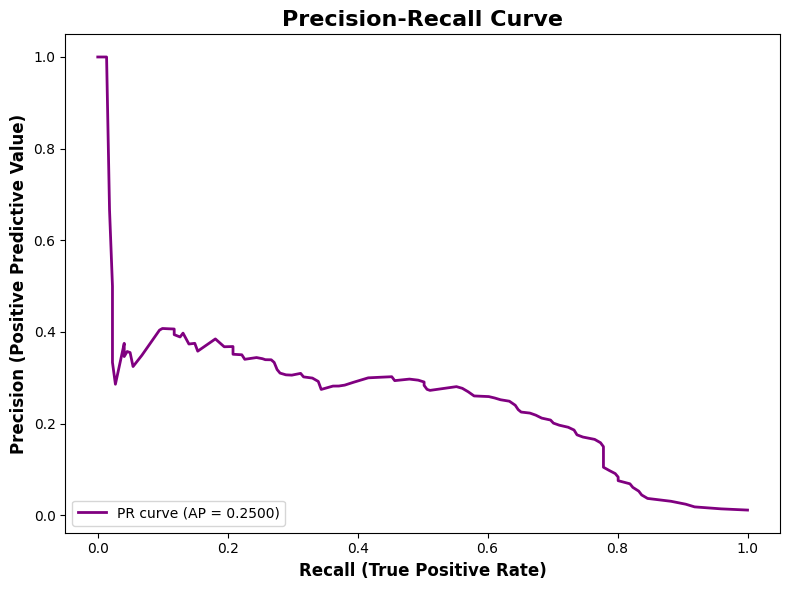

In [7]:
# ==============================================================================
# CELL 7 : PRECISION-RECALL CURVE
# ==============================================================================
"""
### What is this code about?
* We calculate and plot the Precision-Recall (PR) curve, which evaluates the model's performance specifically focused on the minority class (Fraud).

### Why are we doing this?
* For highly imbalanced datasets, the ROC curve can sometimes paint an overly optimistic picture. The PR curve is much more sensitive to False Positives in imbalanced scenarios.

### What is the main reason behind it (intent)?
* To give the business team a realistic view of how accurate the model is when it actually flags a transaction. We want high recall (catching fraud) without destroying precision (annoying innocent customers).

### What will be the result?
* A plot showing the trade-off between Precision and Recall. The closer the curve is to the top-right corner, the better.
"""
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1. Calculate Precision, Recall, and thresholds
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_prob)

# 2. Calculate the Average Precision (AP) score
avg_precision = average_precision_score(y_test, y_pred_prob)

# 3. Plot the PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='purple', lw=2, label=f'PR curve (AP = {avg_precision:.4f})')
plt.xlabel('Recall (True Positive Rate)', fontsize=12, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=12, fontweight='bold')
plt.title('Precision-Recall Curve', fontsize=16, fontweight='bold')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# CELL 8 : SAVING THE TRAINED MODEL FOR PRODUCTION
# ==============================================================================
"""
### What is this code about?
* We use the `joblib` library to serialize (save) our trained Random Forest model to a file on the hard drive.

### Why are we doing this?
* Training a Random Forest model on hundreds of thousands of rows takes time and compute resources. 
  We don't want to retrain it every time we need to check a new transaction.

### What is the main reason behind it (intent)?
* This acts as the bridge between Week 3 (Model Development) and Week 4 (Deployment/Inference). 
  By saving the model as a `.pkl` (pickle) file, we freeze its current "learned" state so it 
  can be loaded instantly into a web app or API later.

### What will be the result?
* A file named `random_forest_fraud_model.pkl` will be created in your directory.
* We print a success message confirming the model is ready for deployment.
"""
import joblib
import os

# 1. Define the filename for the saved model
model_filename = 'random_forest_fraud_model.pkl'

# 2. Save the model to disk
joblib.dump(model, model_filename)

# 3. Verify the file exists and print confirmation
if os.path.exists(model_filename):
    file_size = os.path.getsize(model_filename) / (1024 * 1024) # Convert bytes to MB
    print(f"SUCCESS! Model saved successfully as '{model_filename}'.")
    print(f"File Size: {file_size:.2f} MB")
    print("Week 3 is now complete. The model is ready for deployment in Week 4!")
else:
    print("ERROR: Model failed to save.")

SUCCESS! Model saved successfully as 'random_forest_fraud_model.pkl'.
File Size: 57.54 MB
Week 3 is now complete. The model is ready for deployment in Week 4!


In [ ]:
# ==============================================================================
# WEEK 3 - CELL 9 : UNSUPERVISED ANOMALY DETECTION (ISOLATION FOREST)
# ==============================================================================
"""

1. What is Unsupervised Learning?
Supervised models (like Random Forest) require historical data labeled as 'Fraud' 
or 'Legitimate'. Unsupervised models do not use labels. They look at the raw data 
and find transactions that look completely different from everything else.

2. How does Isolation Forest work?
Imagine standing in a crowd of 1,000 people dressed in white shirts, and one person 
dressed in a neon green suit. 
To isolate a person in a white shirt, you would need to draw many lines through the crowd. 
To isolate the person in neon green, you only need one line.
Isolation Forest randomly cuts the data. Unusual transactions (anomalies) are isolated 
very quickly with few cuts, while normal transactions take many cuts.

3. Why do we need both Supervised and Unsupervised models?
- Supervised (Random Forest): Catches KNOWN fraud methods we have seen in the past.
- Unsupervised (Isolation Forest): Catches NEW/UNKNOWN fraud tactics that hackers just invented.

### STEP-BY-STEP CODE EXPLANATION
Below is the breakdown of what every section of this code does.
"""

# ------------------------------------------------------------------------------
# STEP 1: IMPORT REQUIRED LIBRARIES
# ------------------------------------------------------------------------------
# IsolationForest is the unsupervised anomaly detection algorithm from scikit-learn.
from sklearn.ensemble import IsolationForest
import joblib
import os
import pandas as pd

# ------------------------------------------------------------------------------
# STEP 2: INITIALIZE AND TRAIN THE ISOLATION FOREST MODEL
# ------------------------------------------------------------------------------
# 'contamination': Estimated percentage of anomalies in the dataset (e.g., 0.01 = 1% fraud).
# 'random_state': Ensures reproducible results every time the code runs.
# 'n_jobs=-1': Uses all available CPU cores to speed up processing.
isolation_model = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)

# We fit the model on our training features (X_train). 
# Notice we DO NOT pass y_train (labels) because this is unsupervised learning.
print("Training Isolation Forest Anomaly Detection Model...")
isolation_model.fit(X_train)
print("Training Complete.")

# ------------------------------------------------------------------------------
# STEP 3: EVALUATE ANOMALY SCORES ON TEST DATA
# ------------------------------------------------------------------------------
# Isolation Forest outputs two values:
# 1. predict(): Returns -1 for anomalies (Fraud) and 1 for normal data.
# 2. decision_function(): Returns an anomaly score. Lower numbers mean higher risk.

test_predictions = isolation_model.predict(X_test)
test_scores = isolation_model.decision_function(X_test)

# Convert outputs into readable binary indicators (1 for Fraud, 0 for Normal)
# If prediction == -1, it is flagged as an anomaly (1)
anomalies_detected = (test_predictions == -1).sum()
total_test_records = len(X_test)

print(f"Total Test Transactions Evaluated: {total_test_records}")
print(f"Anomalies Flagged by Isolation Forest: {anomalies_detected}")

# ------------------------------------------------------------------------------
# STEP 4: SAVE THE TRAINED MODEL FOR WEEK 4 DEPLOYMENT
# ------------------------------------------------------------------------------
iso_model_filename = 'isolation_forest_fraud_model.pkl'

# Save model object to disk
joblib.dump(isolation_model, iso_model_filename)

if os.path.exists(iso_model_filename):
    file_size = os.path.getsize(iso_model_filename) / (1024 * 1024)
    print(f"SUCCESS: Model saved as '{iso_model_filename}' ({file_size:.2f} MB)")
    print("Both Supervised (Random Forest) and Unsupervised (Isolation Forest) models are ready.")
else:
    print("ERROR: Failed to save Isolation Forest model.")

Training Isolation Forest Anomaly Detection Model...
Training Complete.
Total Test Transactions Evaluated: 20000
Anomalies Flagged by Isolation Forest: 330
SUCCESS: Model saved as 'isolation_forest_fraud_model.pkl' (1.47 MB)
Both Supervised (Random Forest) and Unsupervised (Isolation Forest) models are ready.
